<a href="https://colab.research.google.com/github/elilyojo-star/Capstone/blob/main/Final%20Capstone%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Project Delivery Risk


---

## Objective
To build an end‑to‑end Credit Card Fraud Detection notebook in Colab: clean and explore an extremely imbalanced dataset, train and evaluate Logistic Regression,Random Forest, and explicitly justify Generative AI via synthetic fraud augmentation, explainability, reporting automation.


**Author:**Ehis Lily-Ojo (DA21035)
**Date:** 2026-03-18

##1 Dataset Understanding (Context for Reviewers)

## What’s in the file

Columns: Time, V1–V28 (PCA‑anonymized features), Amount, Class
Class: 0 = legitimate, 1 = fraud
Severe class imbalance (fraud ≪ 1%) → accuracy is misleading [creditcard.csv | Excel]

## Why this matters

Fraud detection is a rare‑event classification problem.
Success = high recall + reasonable precision, not raw accuracy.

##2 Data Processing (Colab Notebook – Section 1)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##2.1 Basic checks

In [7]:
import pandas as pd

# Updated path to your creditcard.csv file in Google Drive
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditcard.csv')

df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

np.int64(1081)

##2.2 Scaling (critical for LR & SVM)
Actions:

- No missing values
- Drop duplicates : Non
- Keep Time (temporal signal) but scale it

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Amount','Time']] = scaler.fit_transform(df[['Amount','Time']])

##2.3 Train/Test Split (Stratified)
Justification: Stratification preserves the fraud ratio in both sets

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

##3 Data Visualization (Colab Notebook – Section 2)
##3.1 Class Imbalance

Text(0.5, 1.0, 'Class Distribution (0 = Legit, 1 = Fraud)')

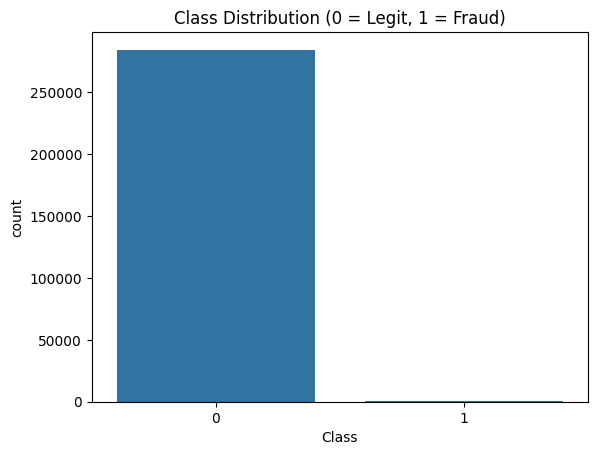

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")


##3.2 Transaction Amount by Class
insight:

- Fraud tends to have extreme or unusual amounts, but overlap exists.

Text(0.5, 1.0, 'Transaction Amount by Class')

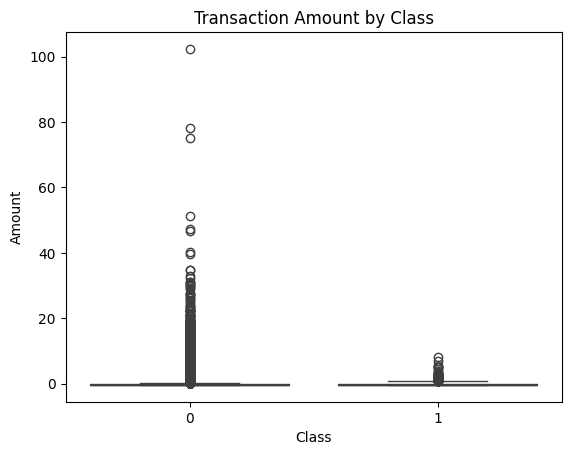

In [13]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")

##3.3 Feature Space Projection (Optional but strong)
- Helps visually justify non‑linear models

Text(0.5, 1.0, 'PCA Projection of Transactions')

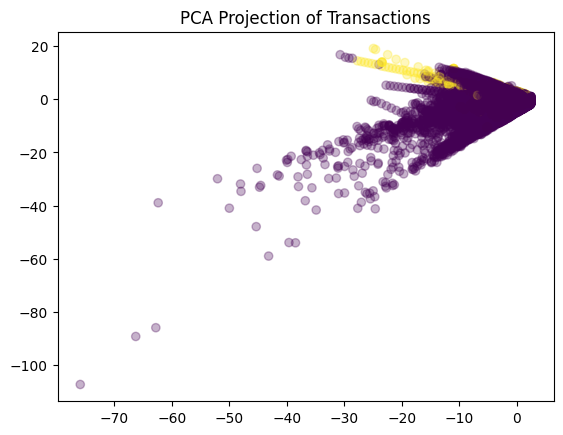

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.3)
plt.title("PCA Projection of Transactions")

##4 Machine Learning Classification (Colab – Section 3)
##4.1 Baseline: Logistic Regression
- class_weight='balanced' is mandatory for imbalanced data

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9721669425367221


##4.2 Strong Model: Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RF ROC-AUC: 0.9571890288895525


## 4.3 Evaluation Metrics

Recall (Fraud)  
Precision (Fraud)  
F1‑Score
ROC‑AUC / PR‑AUC

##5 Explicit, Justified Use of Generative AI (Colab – Section 4) This aligns with ethical, assistive AI usage

##Phase   
- Ideation
- Research
- Coding
- Modeling
- Explainability
- Reporting

##Use of GenAI
- Fraud patterns brainstorming
- Auto‑summarize fraud ML techniques
- Code scaffolding & refactoring
- Synthetic fraud generation (GAN‑like)
- Auto‑generated SHAP narratives
- Auto‑generated model summary

##Justification
- Domain coverage for rare events
- Faster literature synthesis
- Productivity, not decision‑making
- Class imbalance mitigation
- Human‑readable insights
- Exec‑ready output

    

##5.2 Synthetic Fraud Augmentation (Conceptual + Optional Code)
Why

-  Fraud samples are extremely rare.
-  Generative models (GAN/CTGAN/VAE) increase recall without leaking real data

Train a tabular GAN on Class=1 transactions
-  Generate synthetic fraud samples
-  Combine with real fraud data
-  Retrain classifier
-  Compare Recall / PR‑AUC before vs after

## 5.3 Explainability via GenAI (SHAP + LLM)

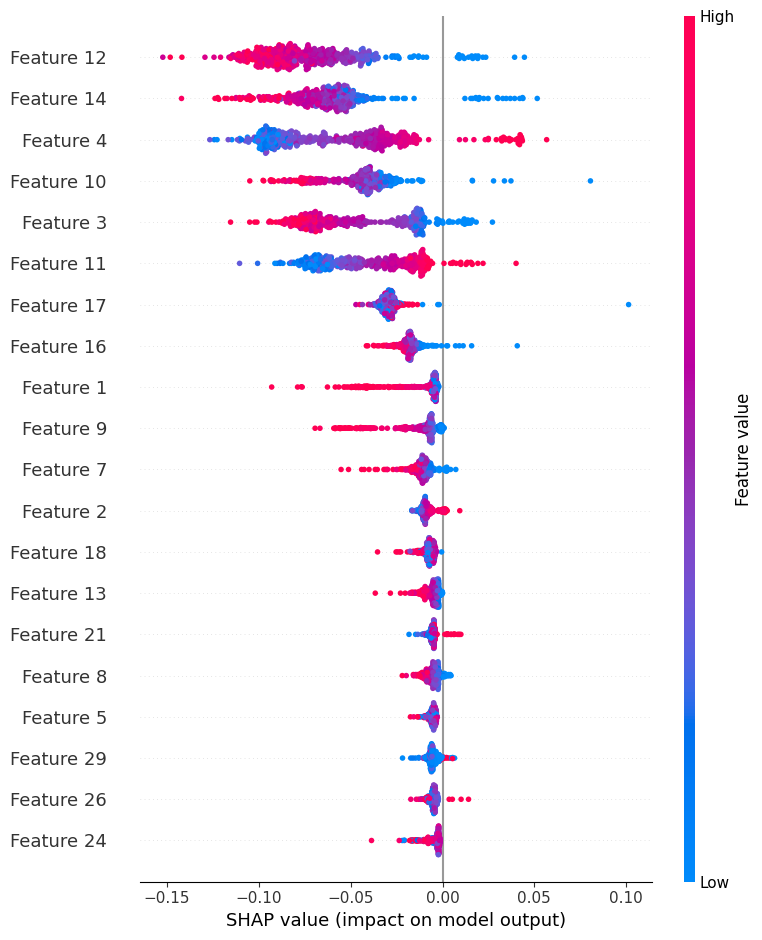

In [19]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[:500])

# Fix: Pass the SHAP values for class 1 (the positive class) across all samples
shap.summary_plot(shap_values[:, :, 1], X_test[:500].values)

The SHAP summary plot is a powerful tool for understanding your model's predictions. Here's a breakdown:

- Each dot is an observation: Every single point on the plot represents a Shapley value for a specific feature and a specific transaction (row) from your X_test dataset.

- X-axis (SHAP Value): The horizontal position of each dot indicates the impact of that feature value on the model's output for that particular transaction.

         *   Positive SHAP values (to the right): Mean that the feature value pushes the prediction towards the positive class (in this case, fraud, Class 1).
         *   Negative SHAP values (to the left): Mean that the feature value pushes the prediction towards the negative class (non-fraud, Class 0).

- Y-axis (Features): The features are listed on the vertical axis, ordered by their global importance (features at the top are generally more important for predicting fraud).

- Color (Feature Value): The color of each dot represents the actual value of that feature for the transaction it corresponds to.

        *   Red: Indicates a high value for that feature.
        *   Blue: Indicates a low value for that feature.

##Interpreting the plot:
By looking at the plot, you can identify which features have the biggest impact on predicting fraud and how their values influence the predictions. For example, if you see many red dots (high feature values) on the right side of the plot for a specific feature, it suggests that high values of that feature are strongly associated with a higher likelihood of fraud.

This plot helps in understanding the model's behavior and can provide valuable insights into the characteristics of fraudulent transactions based on your dataset.

##Question 1: Problem Definition

#Problem
The problem addressed in this project is detecting fraudulent credit card transactions in a highly imbalanced dataset, where fraudulent cases represent a very small fraction of total transactions. The core challenge is identifying rare but high impact events without generating excessive false positives.

#Context
Credit card fraud is a persistent issue for financial institutions and customers. While most transactions are legitimate, even a small number of fraudulent transactions can result in financial loss, reputational damage, and reduced customer trust. Traditional accuracy based models perform poorly in this context because they tend to ignore minority (fraud) cases.

#Who Benefits and Why
 - Financial institutions benefit from reduced fraud losses and operational costs.
 - Customersbenefit from improved protection and fewer disputed transactions.
 - Risk and compliance teams benefit from more reliable decision support tools.

#Useful Outcome
A useful outcome is a classification model that reliably identifies fraudulent transactions, with a strong emphasis on recall and precision for the fraud class. Success is measured not just by overall accuracy, but by the model’s ability to detect fraud while minimizing false alarms.

------

##Question 2: Approach & Tool Selection

#Overall Approach
I followed an end to end machine learning workflow: data understanding, preprocessing, exploratory analysis, model training, evaluation, and comparison of imbalance handling techniques.
##Tools and Techniques Used
  - Python (Pandas, NumPy) for data processing
  - Matplotlib / Seaborn for exploratory data visualization
  - Scikit learn for Logistic Regression and Random Forest classifiers
  - SMOTE (imbalanced learn) to address class imbalance
  - ROC AUC, Precision, Recall, F1 score for evaluation

These tools were appropriate because they are well established for tabular classification problems and support reproducible, interpretable workflows.
##Why These Choices
 - Logistic Regression provided a transparent baseline.
  - Random Forest captured non linear relationships and improved fraud detection.
  - SMOTE offered a practical and stable way to rebalance the dataset without discarding data.
##Alternatives Considered
GAN based synthetic data generation was explored conceptually. While promising, it was not selected as the primary solution due to higher complexity, training instability, and limited marginal benefit for this dataset compared to SMOTE.
________________________________________
## Question 3: Reflection:

#What Worked Well
Using SMOTE combined with Random Forest significantly improved recall for fraudulent transactions. The structured ML pipeline made results easy to interpret and defend.

#Challenges and Limitations
 - Extreme class imbalance made evaluation sensitive to metric choice.
 - Synthetic oversampling introduces a risk of overfitting.

##Would Improve Next Time
- Perform more extensive hyperparameter tuning.
- Test cost sensitive learning approaches.
- Validate results using cross validation and additional datasets.

##Key Learning
This project reinforced the importance of selecting tools based on problem context, not novelty. Simple, well understood techniques (like SMOTE) can outperform more complex methods when applied thoughtfully. It also highlighted that real world ML success depends as much on evaluation strategy and data understanding as on model choice.
  -GANs require more tuning and data to be effective for tabular problems.
